In [1]:
import os, sys
sys.path.append(os.path.join(os.environ.get('IDEFIX_DIR','../../../../'), 'pytools'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import dump_io as io

from astropy import constants as const, units as u

%matplotlib inline


In [2]:
dirc = 'out/'

def load(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer][0]
def load3D(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer]

snap = 100

In [3]:
dmp = io.readDump(f'{dirc}/dump.0000.dmp')
r, th, phi = dmp.x1, dmp.x2, dmp.x3


uL = 1e8 *u.cm.cgs
uM = 1e24*u.g.cgs
uv = 1e5*u.cm.cgs/u.s.cgs
uT = ((u.g.cgs/u.mol.cgs) * uv**2 / (const.k_B.cgs * const.N_A.cgs)).decompose()
ud = uM/uL**3

mu = 30

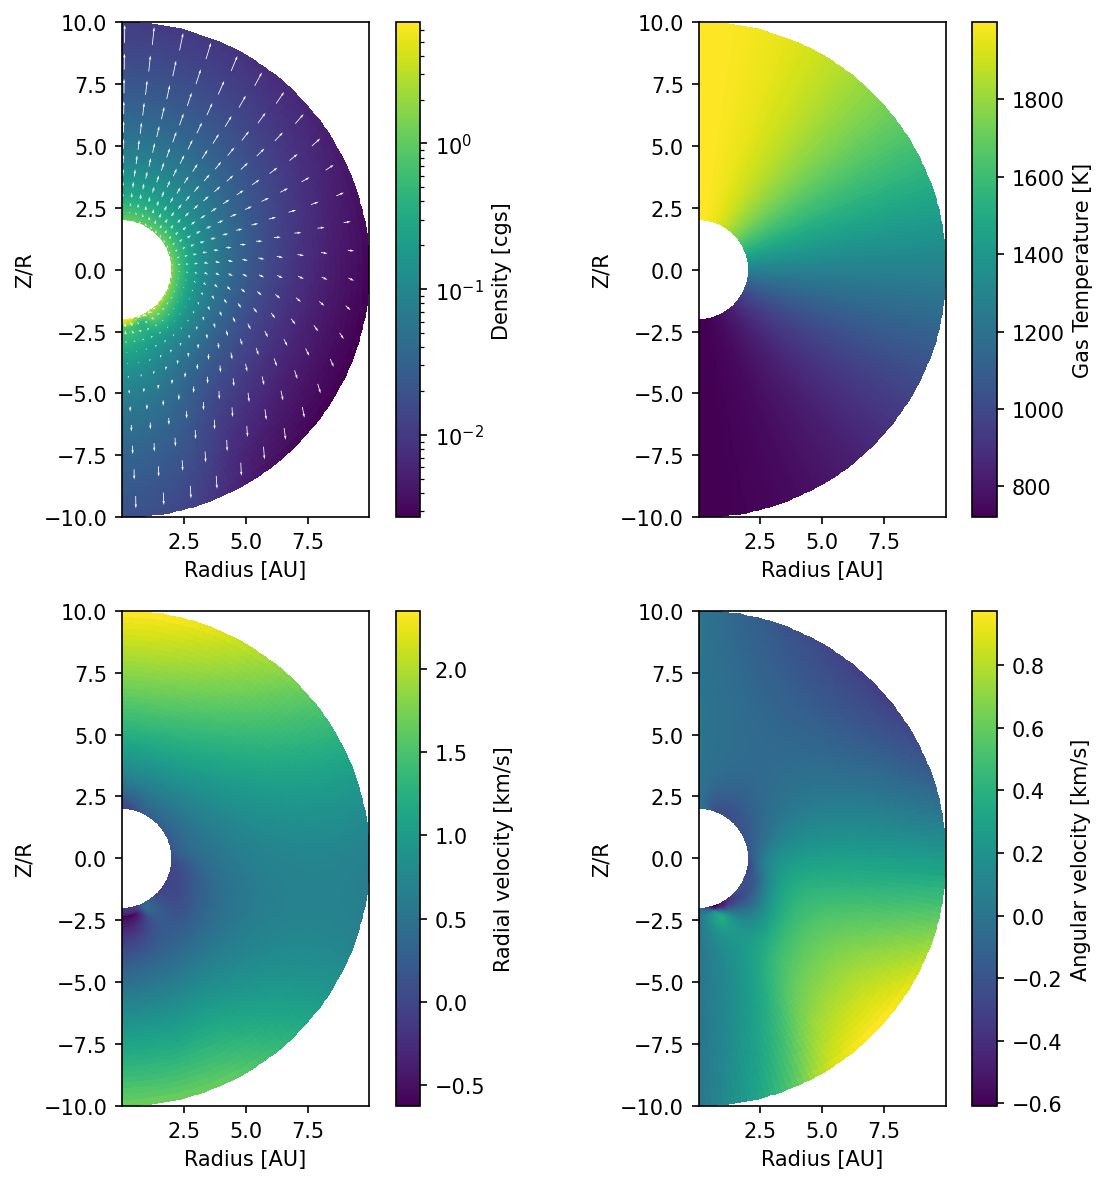

In [4]:
fig, ax = plt.subplots(2, 2, dpi=150, figsize=(8,8))
ax[0,0].set_aspect('equal')
ax[0,1].set_aspect('equal')
ax[1,0].set_aspect('equal')
ax[1,1].set_aspect('equal')



rho = load(i=snap, var='Vc-RHO')

vr = load(i=snap, var='Vc-VX1')
vth = load(i=snap, var='Vc-VX2')

amp = 0.25
T = np.full_like(rho, 2000) * ((1 + amp*np.cos(th[:,None])) / (1 + amp))**2

z = r*np.cos(th[:,None])
x = r*np.sin(th[:,None])

vz = vr * np.cos(th[:,None]) - vth * np.sin(th[:,None])
vx = vr * np.sin(th[:,None]) + vth * np.cos(th[:,None])

im = ax[0,0].pcolormesh(x, z, rho * ud.to_value('g/cm**3'), norm=LogNorm())
ax[0,0].set_xlabel('Radius [AU]')
ax[0,0].set_ylabel('Z/R')
ax[0,0].quiver(x[::5,::5], z[::5,::5], vx[::5,::5], vz[::5,::5], color='white', scale=30)
fig.colorbar(im, ax=ax[0,0], label='Density [cgs]')

im = ax[0,1].pcolormesh(x, z, T)
ax[0,1].set_xlabel('Radius [AU]')
ax[0,1].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[0,1], label='Gas Temperature [K]')

im = ax[1,0].pcolormesh(x, z, vr * uv.to_value('cm/s') /1e5)
ax[1,0].set_xlabel('Radius [AU]')
ax[1,0].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[1,0], label='Radial velocity [km/s]')

im = ax[1,1].pcolormesh(x, z, vth * uv.to_value('cm/s') /1e5)
ax[1,1].set_xlabel('Radius [AU]')
ax[1,1].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[1,1], label='Angular velocity [km/s]')

fig.tight_layout()


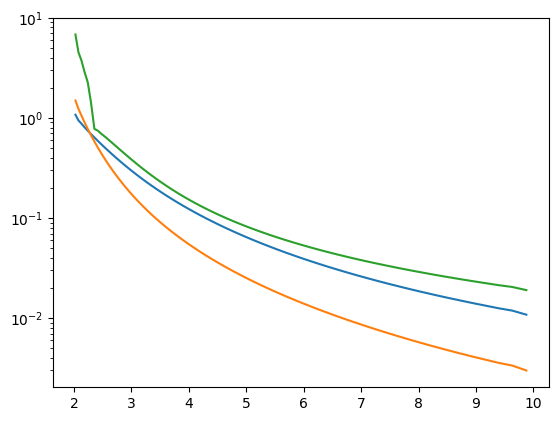

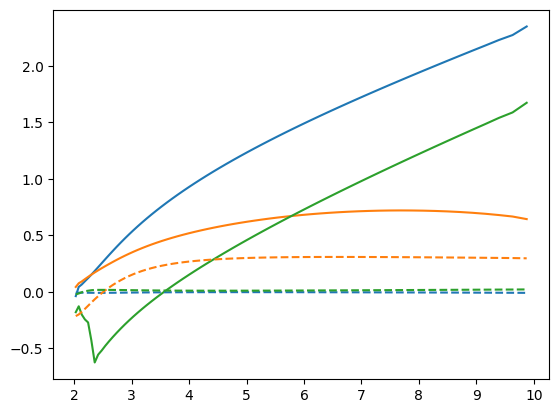

In [5]:
plt.plot(r, rho[0])
plt.plot(r, rho[65])
plt.semilogy(r, rho[-1])


plt.figure()
plt.plot(r, vr[0])
plt.plot(r, vr[65])
plt.plot(r, vr[-1])

plt.plot(r, vth[0], ls='--',  c='C0')
plt.plot(r, vth[65],  ls='--', c='C1')
plt.plot(r, vth[-1], ls='--', c='C2')